In [1]:
!nvidia-smi

Mon Mar 30 17:55:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
%pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.9 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=f214c20a1d174491e978dba5b6d16ebee67a452e4a62fe5bf7557b7779007ce1
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [4]:
import numpy as np
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import time

# CUDA-код для умножения матриц.
# Ядро компилируется один раз при загрузке модуля, а не при каждом вызове функции.
matrix_mul_kernel = """
__global__ void matrixMulKernel(float* a, float* b, float* c, int rows_a, int cols_a, int cols_b) {
    // Каждый поток вычисляет один элемент результирующей матрицы C[row][col]
    int row = blockIdx.y * blockDim.y + threadIdx.y; // Индекс строки
    int col = blockIdx.x * blockDim.x + threadIdx.x; // Индекс столбца

    if (row < rows_a && col < cols_b) {
        float value = 0.0f;
        // Каждый поток независимо вычисляет скалярное произведение
        // строки row матрицы A и столбца col матрицы B
        for (int k = 0; k < cols_a; k++) {
            value += a[row * cols_a + k] * b[k * cols_b + col];
        }
        c[row * cols_b + col] = value;
    }
}
"""

# Компиляция ядра выполняется один раз при запуске ячейки,
# а не при каждом вызове matrix_multiply_gpu
mod = SourceModule(matrix_mul_kernel)
matrix_mul_func = mod.get_function("matrixMulKernel")


def matrix_multiply_cpu(A, B):
    '''
    Функция для выполнения умножения матриц на CPU (тройной цикл, O(N^3)).
    :param A: первая матрица (numpy array, float32)
    :param B: вторая матрица (numpy array, float32)
    :return: (answer, elapsed_time) — результат умножения и время в секундах
    '''
    if A.shape[1] != B.shape[0]:
        raise ValueError("Неправильные размеры матриц для перемножения")

    answer = np.zeros((A.shape[0], B.shape[1]), dtype=np.float32)

    start_time = time.time()
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            for k in range(A.shape[1]):
                answer[i, j] += A[i, k] * B[k, j]
    end_time = time.time()

    return answer, end_time - start_time


def matrix_multiply_gpu(A, B):
    '''
    Функция для выполнения умножения матриц на GPU с использованием PyCUDA.
    Замеряется только время вычисления (без компиляции ядра).
    :param A: первая матрица (numpy array, float32)
    :param B: вторая матрица (numpy array, float32)
    :return: (C, elapsed_time) — результат умножения и время в секундах
    '''
    if A.shape[1] != B.shape[0]:
        raise ValueError("Неправильные размеры матриц для перемножения")

    A_height, A_width = A.shape
    B_height, B_width = B.shape
    C = np.zeros((A_height, B_width), dtype=np.float32)

    # Начало замера времени (только вычисление, без компиляции ядра)
    start_time = time.time()

    # Выделение памяти на GPU
    A_gpu = cuda.mem_alloc(A.nbytes)
    B_gpu = cuda.mem_alloc(B.nbytes)
    C_gpu = cuda.mem_alloc(C.nbytes)

    # Копирование входных матриц с CPU на GPU
    cuda.memcpy_htod(A_gpu, A)
    cuda.memcpy_htod(B_gpu, B)

    # Размер блока: 16x16 потоков = 256 потоков на блок (типичное значение для T4)
    block_size = (16, 16, 1)
    grid_size = (
        (B_width  + block_size[0] - 1) // block_size[0],
        (A_height + block_size[1] - 1) // block_size[1]
    )

    # Запуск ядра: каждый поток обрабатывает один элемент матрицы C
    matrix_mul_func(
        A_gpu, B_gpu, C_gpu,
        np.int32(A_height), np.int32(A_width), np.int32(B_width),
        block=block_size, grid=grid_size
    )

    # Ждём завершения всех потоков GPU перед копированием результата
    cuda.Context.synchronize()

    # Копирование результата с GPU обратно на CPU
    cuda.memcpy_dtoh(C, C_gpu)

    end_time = time.time()

    return C, end_time - start_time


if __name__ == "__main__":
    size = (2000, 2000)
    low, high = 1, 10

    # Явно задаём dtype=float32, чтобы гарантировать совместимость с CUDA-ядром
    matrix_a = np.random.randint(low, high, size).astype(np.float32)
    matrix_b = np.random.randint(low, high, size).astype(np.float32)

    # Эталонный результат через numpy
    answer_reference = np.dot(matrix_a, matrix_b)

    # Умножение на GPU
    answer_gpu, time_gpu = matrix_multiply_gpu(matrix_a, matrix_b)
    print(f"Результат на GPU:\n{answer_gpu}")
    print(f"Соответствие результата с np.dot(): {np.allclose(answer_gpu, answer_reference)}")
    print(f"Время на GPU: {time_gpu:.6f} секунд\n")

    # Умножение на CPU
    answer_cpu, time_cpu = matrix_multiply_cpu(matrix_a, matrix_b)
    print(f"Результат на CPU:\n{answer_cpu}")
    print(f"Соответствие результата с np.dot(): {np.allclose(answer_cpu, answer_reference)}")
    print(f"Время на CPU: {time_cpu:.6f} секунд")

    print(f"\nУскорение (CPU / GPU): {time_cpu / time_gpu:.2f}x")


Результат на GPU:
[[50464. 50393. 50897. ... 51843. 51160. 51691.]
 [50436. 50705. 50625. ... 52096. 49559. 51383.]
 [50790. 50944. 51063. ... 52268. 50795. 52403.]
 ...
 [50567. 50572. 51154. ... 52031. 50137. 51515.]
 [50171. 50499. 50256. ... 51856. 49788. 50778.]
 [51109. 51948. 50211. ... 52259. 50773. 52265.]]
Соответствие результата с np.dot(): True
Время на GPU: 0.084352 секунд

Результат на CPU:
[[50464. 50393. 50897. ... 51843. 51160. 51691.]
 [50436. 50705. 50625. ... 52096. 49559. 51383.]
 [50790. 50944. 51063. ... 52268. 50795. 52403.]
 ...
 [50567. 50572. 51154. ... 52031. 50137. 51515.]
 [50171. 50499. 50256. ... 51856. 49788. 50778.]
 [51109. 51948. 50211. ... 52259. 50773. 52265.]]
Соответствие результата с np.dot(): True
Время на CPU: 5349.216718 секунд

Ускорение (CPU / GPU): 63415.40x


## Эксперименты: перемножение матриц разных размеров

      Размер |      CPU (сек) |    GPU (сек) |    Ускорение
----------------------------------------------------------
     100x100 |       0.791502 |     0.001850 |       427.84x
     480x480 |      84.078420 |     0.003558 |     23630.81x
     860x860 |     473.219588 |     0.010889 |     43458.50x
   1240x1240 |    1420.735224 |     0.024501 |     57986.83x
   1620x1620 |    3183.791578 |     0.051493 |     61829.60x
   2000x2000 |    5977.909498 |     0.083697 |     71423.22x


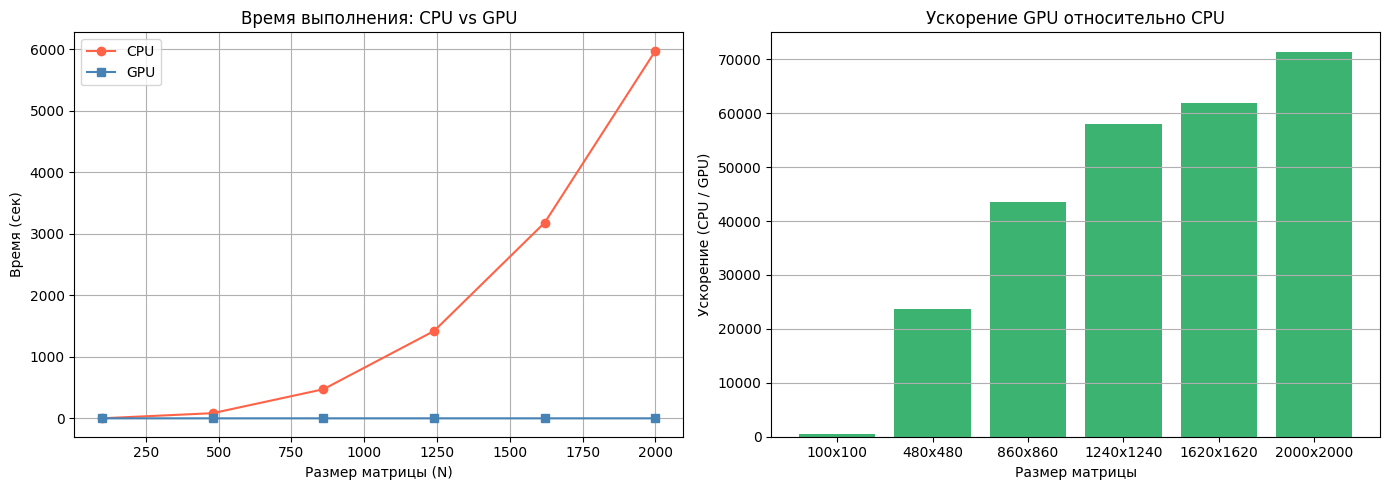

График сохранён в speedup_chart.png


In [5]:
import matplotlib.pyplot as plt

sizes     = [100, 480, 860, 1240, 1620, 2000]
times_cpu = [0.791502, 84.078420, 473.219588, 1420.735224, 3183.791578, 5977.909498]
times_gpu = [0.001850, 0.003558,  0.010889,   0.024501,    0.051493,    0.083697]
speedups  = [c / g for c, g in zip(times_cpu, times_gpu)]

print(f"{'Размер':>12} | {'CPU (сек)':>14} | {'GPU (сек)':>12} | {'Ускорение':>12}")
print("-" * 58)
for s, tc, tg, sp in zip(sizes, times_cpu, times_gpu, speedups):
    print(f"{str(s)+'x'+str(s):>12} | {tc:>14.6f} | {tg:>12.6f} | {sp:>12.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sizes, times_cpu, 'o-', color='tomato',   label='CPU')
axes[0].plot(sizes, times_gpu, 's-', color='steelblue', label='GPU')
axes[0].set_xlabel('Размер матрицы (N)')
axes[0].set_ylabel('Время (сек)')
axes[0].set_title('Время выполнения: CPU vs GPU')
axes[0].legend()
axes[0].grid(True)

axes[1].bar([f"{s}x{s}" for s in sizes], speedups, color='mediumseagreen')
axes[1].set_xlabel('Размер матрицы')
axes[1].set_ylabel('Ускорение (CPU / GPU)')
axes[1].set_title('Ускорение GPU относительно CPU')
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=150)
plt.show()
print("График сохранён в speedup_chart.png")
